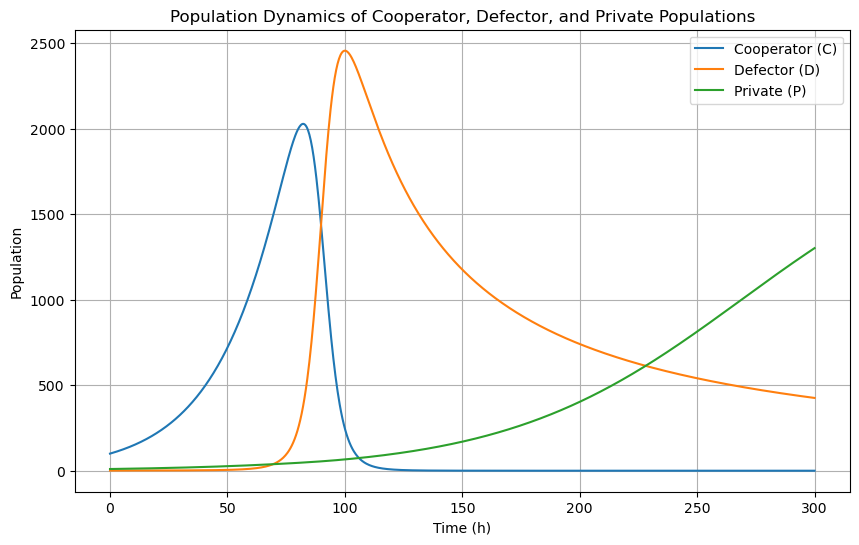

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from modelbase.ode import Model, Simulator

# Create a Model object
m = Model()

# Define model parameters
parameters = {
    'beta': 0.000001,      # competition parameter between public and private
    'lamda': 0.000001,    # competition parameter between public
    'gamma': 0.00001,      # cost for private population
    'alpha': 0.0001,       # benefit from cooperator to defector
    'mu': 0.04,            # growth rate of cooperator
    'eta': 0.02,           # growth rate of private population
    'nu': 0.00001,         # transportation cost of defector
}

# Add parameters to the model
m.add_parameters(parameters)

# Add compounds to the model
m.add_compounds(['C', 'D', 'P'])

# Define the growth rate for cooperator (C)
def cooperator_growth(mu, C, alpha, D, beta, P, lamda):
    return mu * C - alpha * C * D - beta * C * P - lamda * C * C

m.add_reaction_from_args(
    rate_name='cooperator_growth',
    function=cooperator_growth,
    stoichiometry={'C': 1},
    args=['mu', 'C', 'alpha', 'D', 'beta', 'P', 'lamda'],
    reversible=False
)

# Define the growth rate for defector (D)
def defector_growth(alpha, C, D, nu):
    return alpha * C * D - nu * D * D

m.add_reaction_from_args(
    rate_name='defector_growth',
    function=defector_growth,
    stoichiometry={'D': 1},
    args=['alpha', 'C', 'D', 'nu'],
    reversible=False
)

# Define the growth rate for private (P)
def private_growth(eta, P, beta, C, gamma):
    return eta * P - beta * C * P - gamma * P * P

m.add_reaction_from_args(
    rate_name='private_growth',
    function=private_growth,
    stoichiometry={'P': 1},
    args=['eta', 'P', 'beta', 'C', 'gamma'],
    reversible=False
)

# Initial conditions
y0 = {'C': 100.0, 'D': 1.0, 'P': 10.0}

# Create a Simulator object
s = Simulator(m)

# Initialize the simulator with initial conditions
s.initialise(y0)

# Simulate over a time span of 150 hours with 1000 steps
s.simulate(300, steps=1000)

# Extract the population data from the simulator
time = s.get_time()
C = s.get_variable('C')
D = s.get_variable('D')
P = s.get_variable('P')

# Plot the dynamics of each population
plt.figure(figsize=(10, 6))
plt.plot(time, C, label='Cooperator (C)')
plt.plot(time, D, label='Defector (D)')
plt.plot(time, P, label='Private (P)')
plt.xlabel('Time (h)')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.title('Population Dynamics of Cooperator, Defector, and Private Populations')
plt.show()
